# Part A :- Conceptual 

## 1. Generate a dataset from a normal distribution and compute statistics manually

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# Normal Distribution Dataset Analysis
def normal_dataset_analysis(size=1000):
    """ Generates a normal distribution dataset, calculates mean, variance, and standard deviation, and plots the histogram."""
    data = np.random.normal(50, 10, size)
    sum_data = 0
    len_data = 0

     # made use of for loop instead of in-built functions since it was mentioned manually
    for x in data:
        sum_data += x
        len_data += 1

    mean = sum_data / len_data

    diff = 0
    for x in data:
        diff +=(x - mean)**2
    variance = 0
    if len_data:
        variance = diff / len_data
    std_dev = variance ** 0.5

    print("Mean =", mean)
    print("Variance =", variance)
    print("Standard Deviation =", std_dev)

    plt.hist(data, bins=30)
    plt.title("Histogram of Normal Distribution")
    plt.show()

    return data, mean, std_dev


Mean = 50.01514035701337
Variance = 98.37241749959583
Standard Deviation = 9.918287024461222


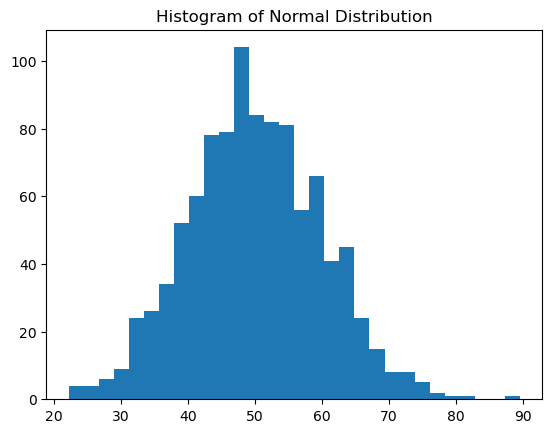

In [53]:
data, mean, std_dev = normal_dataset_analysis()

## 2: Convert dataset into standard normal distribution using Z-score

In [54]:
# Calculate Z-Score using mean and standard deviation
def z_score_conversion(data, mean, std_dev):
    """ Converts a dataset to z-scores, calculates the mean, variance, and standard deviation of the z-scores, and returns the z-scores."""
    z_scores = [(x - mean) / std_dev for x in data]
    sum_score = 0
    count_score = 0

    # made use of for loop instead of in-built functions since it was mentioned manually
    for x in z_scores:
        sum_score += x
        count_score += 1
    z_mean = sum_score / count_score
    
    diff = 0
    for x in z_scores:
        diff +=(x - z_mean)**2
    z_variance = 0
    if count_score:
        z_variance = diff / count_score
    z_std = z_variance ** 0.5

    return z_mean, z_std, z_scores

In [55]:

z_mean, z_std, z_scores = z_score_conversion(data, mean, std_dev)
print("Z-score Mean =", round(z_mean,1))
print("Z-score Standard Deviation =", round(z_std,1))
print("Z-score =", z_scores)

Z-score Mean = 0.0
Z-score Standard Deviation = 1.0
Z-score = [np.float64(0.19536184764049833), np.float64(-0.8444820523395509), np.float64(-1.2968546212630598), np.float64(1.836451993814575), np.float64(0.2426843019088372), np.float64(2.350884661403332), np.float64(-0.03061235234317057), np.float64(0.1395196374358114), np.float64(0.15041443964801332), np.float64(-0.022485165048285398), np.float64(-1.348428798970144), np.float64(0.41376747846906425), np.float64(1.260409392043117), np.float64(-0.5904481953541569), np.float64(-0.7499929339921823), np.float64(-0.7094862206790781), np.float64(-0.6679725997217603), np.float64(0.7668877042216552), np.float64(-0.05427074522492034), np.float64(-1.155715262420463), np.float64(1.7920364295763065), np.float64(0.4716008303964995), np.float64(-0.4252842070400843), np.float64(0.5424964823147734), np.float64(-1.8039993543154729), np.float64(-1.6073917723487117), np.float64(-0.40911461026307133), np.float64(-0.506907456036889), np.float64(-0.953372639

## 3: Compute statistics for student marks and identify outliers

In [56]:
# Mark Analysis using Z-Score
def marks_analysis(marks):
    """ Analyzes a dataset of marks, calculates the mean, median, variance, and standard deviation, and identifies outliers."""
    mean = sum(marks) / len(marks)

    sorted_marks = sorted(marks)
    n = len(sorted_marks)

    if n % 2 == 0:
        median = (sorted_marks[n//2 - 1] + sorted_marks[n//2]) / 2
    else:
        median = sorted_marks[n//2]

    variance = sum((x - mean)**2 for x in marks) / len(marks)
    std_dev = variance ** 0.5

    print("Mean =", mean)
    print("Median =", median)
    print("Variance =", variance)
    print("Standard Deviation =", std_dev)

    print("Outliers:")

    for x in marks:
        z = (x - mean) / std_dev
        if abs(z) > 2:
            print(x)

In [57]:
marks_analysis([45, 50, 52, 48, 49, 51, 47, 100, 46, 53])

Mean = 54.1
Median = 49.5
Variance = 240.09
Standard Deviation = 15.49483785007123
Outliers:
100


## 4: One-sample hypothesis test

In [76]:
# One Sample Hypothesis Testing using Z-Test
def hypothesis_test(data, mu0):
    """ Performs a hypothesis test, calculates the z-statistic, and determines whether to reject or fail to reject the null hypothesis."""
    mean = sum(data) / len(data)
    variance = sum((x - mean)**2 for x in data) / len(data)
    std_dev = variance ** 0.5

    z_stat = (mean - mu0) / (std_dev / (len(data) ** 0.5))

    print("Z-statistic =", z_stat)
    # abs(z) > 1.96 means alpha = 0.05
    if abs(z_stat) > 1.96:
        print("Reject H0")
    else:
        print("Fail to reject H0")


In [77]:
hypothesis_test(data, 50)

Z-statistic = 0.048272461396086534
Fail to reject H0


## 5: Simulate multiple hypothesis tests and estimate false positive rate

In [78]:
# Simulation of False Positive Rate
def false_positive_simulation(trials=1000):
    """ Simulates the false positive rate of a hypothesis test."""
    count = 0
    for _ in range(trials):
        sample = np.random.normal(50, 10, 30)

        mean = sum(sample) / len(sample)
        variance = sum((x - mean)**2 for x in sample) / len(sample)
        std_dev = variance ** 0.5

        z = (mean - 50) / (std_dev / (len(sample) ** 0.5))
        # abs(z) > 1.96 means alpha = 0.05
        if abs(z) > 1.96:
            count += 1

    rate = count / trials

    return rate


In [79]:
print("False Positive Rate =", false_positive_simulation())

False Positive Rate = 0.063


## Part B:- Stretch Problem

### 1. Compare Normal Distribution vs Standard Normal Distribution

In [80]:
import numpy as np
import matplotlib.pyplot as plt

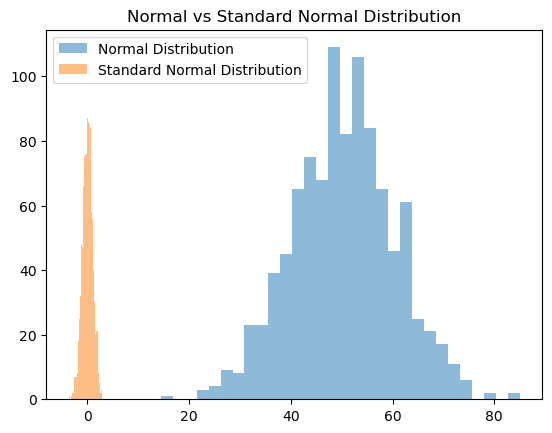

In [81]:
# Generate data
normal_data = np.random.normal(50, 10, 1000)
standard_data = np.random.normal(0, 1, 1000)

# Plot histograms
plt.hist(normal_data, bins=30, alpha=0.5, label='Normal Distribution')
plt.hist(standard_data, bins=30, alpha=0.5, label='Standard Normal Distribution')

plt.legend()
plt.title("Normal vs Standard Normal Distribution")
plt.show()

The main difference is that normal distribution can have any center and spread, while standard normal distribution always uses standardized values called Z-scores. In Python, both can be generated using NumPy, and when plotted, both curves look bell-shaped, but the standard normal curve is centered at zero and narrower compared to a general normal distribution.

## 2. Perform Hypothesis Testing on Two Groups

In [82]:
# Two groups
group1 = np.random.normal(50, 5, 100)
group2 = np.random.normal(55, 5, 100)

# Means
mean1 = np.mean(group1)
mean2 = np.mean(group2)

# Difference
difference = mean2 - mean1

print("Mean Group 1:", mean1)
print("Mean Group 2:", mean2)
print("Difference in Means:", difference)

Mean Group 1: 50.063644372220594
Mean Group 2: 55.438607971601044
Difference in Means: 5.37496359938045


A simple interpretation is: 
- if Group B consistently has higher values than Group A, we may conclude there is evidence of difference between groups. This basic comparison helps understand whether observed changes are likely real or just random variation

## 1. When should you standardize data?
Data should be standardized when features have very different scales, such as age, salary, and height in the same dataset. Standardization converts values to a common scale with mean 0 and standard deviation 1. This helps machine learning algorithms treat all features equally. It is especially useful before using distance-based or gradient-based models.

## 2. Why is Z-score important in machine learning?
Z-score shows how far a value is from the mean in terms of standard deviations. It helps transform data into a standard normal scale so features become comparable. Many algorithms like KNN, SVM, and Logistic Regression perform better with Z-score standardized data. It is also useful for detecting outliers because very high or low Z-scores indicate unusual values.
